## Update a Wflow model: landuse

Once you have a **Wflow** model, you may want to update your model in order to use a new landuse map, change a parameter value, add sample locations, use different forcing data, create and run different scenarios etc.

With HydroMT, you can easily read your model and update one or several components of your model using the **update** function of the command line interface (CLI). Here are the steps and some examples on how to **update the landuse map and parameters**.

All lines in this notebook which starts with ! are executed from the command line. Within the notebook environment the logging messages are shown after completion. You can also copy these lines and paste them in your shell to get more direct feedback.

### Import packages

In this notebook, we will use some functions of HydroMT to check available datasets and also to plot the landuse maps from the original and updated models. Here are the libraries to import to realize these steps.

In [2]:
import numpy as np
import pandas as pd
import hydromt
from hydromt_wflow import WflowSbmModel

# for plotting
import matplotlib as mpl
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

proj = ccrs.PlateCarree()  # plot projection

### Searching the data catalog for landuse

In our previous notebook, we built a Wflow model using the *GlobCover* landuse classification. But we could as well have chosen another one. Let's what other landuse landcover data are available in HydroMT and choose another landuse classification for our model. For this we will open the data catalog.

You can also directly open and search the HydroMT yaml library by downloading and opening the data_catalog.yml file in [hydromt-artifacts](https://github.com/DirkEilander/hydromt-artifacts/releases/tag/v0.0.3) or look at the list of data sources in the [documentation](https://deltares.github.io/hydromt/latest/user_guide/data_catalog/data_existing_cat.html).

In [3]:
# Load the default data catalog of HydroMT
data_catalog = hydromt.DataCatalog("artifact_data")

2026-03-09 15:01:21,206 - hydromt.data_catalog.data_catalog - data_catalog - INFO - Reading data catalog artifact_data latest
2026-03-09 15:01:21,207 - hydromt.data_catalog.data_catalog - data_catalog - INFO - Parsing data catalog from C:\Users\matti\.hydromt\artifact_data\v1.0.0\data_catalog.yml


In [4]:
# Check which landuse/lancover sources are available in the DataCatalog
data_table = data_catalog._to_dataframe()
data_table[data_table["category"] == "landuse & landcover"]

,provider,version,uri,data_type,driver,crs,category,paper_doi,paper_ref,url,license,author,unit,history,notes,nodata,info,processing_notes,timestamp
name,,,,,,,,,,,,,,,,,,,
corine,None,v.2020_20u1,corine.tif,RasterDataset,RasterioDriver,NaN,landuse & landcover,NaN,NaN,https://land.copernicus.eu/pan-european/corine...,https://land.copernicus.eu/pan-european/corine...,European Environment Agency,NaN,NaN,NaN,NaN,NaN,NaN,NaN
globcover_2009,None,NaN,globcover.tif,RasterDataset,RasterioDriver,4326,landuse & landcover,10.1594/PANGAEA.787668,Arino et al (2012),http://due.esrin.esa.int/page_globcover.php,CC-BY-3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
modis_lai,None,6,modis_lai.nc,RasterDataset,RasterDatasetXarrayDriver,4326,landuse & landcover,10.5067/MODIS/MCD15A3H.006,Myneni et al (2015),https://lpdaac.usgs.gov/products/mcd15a3hv006/,https://lpdaac.usgs.gov/data/data-citation-and...,NaN,NaN,NaN,this dataset has been extracted from GEE ('MOD...,NaN,NaN,NaN,NaN
simard,None,NaN,simard.tif,RasterDataset,RasterioDriver,4326,landuse & landcover,10.1029/2011JG001708,Simard et al (2011),https://webmap.ornl.gov/ogc/dataset.jsp?ds_id=...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
vito_2015,None,2.0.2,vito.tif,RasterDataset,RasterioDriver,4326,landuse & landcover,10.5281/zenodo.3939038,Buchhorn et al (2020),https://land.copernicus.eu/global/products/lc,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Here we can see that we have five data sources in HydroMT related to landuse & landcover properties. Out of these, three are landuse classifications:

- **globcover_2009** (already used in our current model)
- **corine**
- **vito_2015**

The other datasets include a Leaf Area Index dataset (modis_lai) and a canopy height dataset (simard).

Let's now see how to update our current model in one command line to use the **corine** classification.

### HydroMT CLI update interface

Using the **HydroMT build** API, we can update one or several components of an already existing Wflow model. Let's get an overview of the available options:

In [5]:
# Print the options available from the update command
! hydromt update --help

Usage: hydromt update [OPTIONS] MODEL MODEL_ROOT

  Update a specific component of a model.

  Set an output directory to copy the edited model to a new folder, otherwise
  maps are overwritten.

  Example usage: --------------

  Update Wflow model components outlined in an .yml configuration file and
  write the model to a directory: hydromt update wflow_sbm /path/to/model_root
  -o /path/to/model_out  -i /path/to/wflow_config.yml  -d
  /path/to/data_catalog.yml -v

Options:
  -o, --model-out DIRECTORY  Output model folder. Maps in MODEL_ROOT are
                             overwritten if left empty.
  -i, --config PATH          Path to hydroMT configuration file, for the model
                             specific implementation.  [required]
  -d, --data TEXT            Path to local yaml data catalog file OR name of
                             predefined data catalog.
  --dd, --deltares-data      Flag: Shortcut to add the "deltares_data" catalog
  --fo, --force-overwrite    Flag:

### Model setup configuration

To let HydroMT know which setup method to call and the options, you can prepare and use a **configuration file** that includes every methods and settings that you want to do during your update.

The HydroMT configuration file (YAML) contains the model setup configuration and determines which methods are updated and in which sequence and sets optional arguments for each method. This configuration is passed to hydromt using `-i <path_to_config_file>`.

Each header (without indent) (e.g. `setup_lulcmaps:`) corresponds with a model method which are explained in the [docs (model methods)](https://deltares.github.io/hydromt_wflow/latest/user_guide/wflow_model_setup.html).

Let's open the example configuration file **wflow_update_landuse.yml** from the model repository [examples folder] and have a look at the settings.

In [6]:
fn_config = "wflow_update_landuse.yml"
with open(fn_config, "r") as f:
    txt = f.read()
print(txt)

steps:
  - setup_lulcmaps:
      lulc_fn : corine     # source for lulc maps: {globcover, vito, corine}
      lulc_mapping_fn: corine_mapping_default  # default mapping for lulc classes
      output_names_suffix: corine # add a suffix to the output map names in staticmaps rather than overwriting existing landuse maps



Here we can see that to fully update wflow forcing, we will run one methods of **Wflow**:

- **setup_lulcmaps**: prepares landuse map and parameters based on a landuse map `lulc_fn` and a mapping table `lulc_mapping_fn` to convert from specific landuse classes (urban, forest) to hydrological parameters (roughness, depth of the vegetation roots etc).

Here, we can see that we will update the landuse with the classification from CORINE and using the HydroMT default mapping table for the parameter creation (HydroMT supports a few of these including "globcover", "corine", "vito" and "esa_worldcover"). If you want to use a different classification or update the default values (eg for calibration), you can create and catalog your own table.

We will also here save the different maps with the suffix "corine" via the `output_names_suffix` options. If this option is not provided (or None), the new maps will overwrite previously existing ones. Here we will keep both the globcover maps and the new maps from CORINE in the updated model.

You can find more information about the different options in the [docs (setup lulcmaps)](https://deltares.github.io/hydromt_wflow/latest/_generated/hydromt_wflow.WflowBaseModel.setup_lulcmaps.html#hydromt_wflow.WflowBaseModel.setup_lulcmaps)

### Update Wflow landuse layers

In [7]:
# NOTE: copy this line (without !) to your shell for more direct feedback
! hydromt update wflow_sbm wflow_piave_subbasin -o ./wflow_piave_corine -i wflow_update_landuse.yml -d artifact_data -v

2026-03-09 15:01:29,298 - hydromt - log - INFO - HydroMT version: 1.3.0
2026-03-09 15:01:29,579 - hydromt.data_catalog.data_catalog - data_catalog - INFO - Reading data catalog artifact_data latest
2026-03-09 15:01:29,579 - hydromt.data_catalog.data_catalog - data_catalog - INFO - Parsing data catalog from C:\Users\matti\.hydromt\artifact_data\v1.0.0\data_catalog.yml
2026-03-09 15:01:30,322 - hydromt.model.model - model - INFO - Initializing wflow_sbm model from hydromt_wflow (v1.0.1).
2026-03-09 15:01:30,322 - hydromt.data_catalog.data_catalog - data_catalog - INFO - Parsing data catalog from C:\Users\matti\miniconda3\envs\hydromt-wflow\Lib\site-packages\hydromt_wflow\data\parameters_data.yml
2026-03-09 15:01:30,343 - hydromt.hydromt_wflow.wflow_base - wflow_base - INFO - Supported Wflow.jl version v1+
2026-03-09 15:01:30,344 - hydromt.hydromt_wflow.components.config - config - INFO - Reading model config file from C:/Data/TUD/MSc_CE/Courses/2nd_year/7.CIE5060_Thesis/Codes/MSc_thesis_

The example above means the following: run **hydromt** with:

- `update wflow`: i.e. update a wflow model
- `wflow_piave_subbasin`: original model folder
- `-o ./wflow_piave_corine`: output updated model folder
- `-i wflow_update_landuse.yml`: setup configuration file containing the components to update and their different options
- `-d artifact_data`: specify to use the artifact_data catalog
- `-v`: give some extra verbosity (1 * v) to display feedback on screen. Now INFO messages are provided.

### Model comparison

From the information above, you can see that not only was the landuse map updated but also all wflow landuse-related parameters with it: Kext, N, PathFrac, RootingDepth, Sl, Swood and WaterFrac.

Let's now have a look at the different landuse maps of our two models and check that they were indeed updated.

In [8]:
# Load both models with hydromt
model = WflowSbmModel(root="wflow_piave_corine", mode="r")

2026-03-09 15:01:36,013 - hydromt.model.model - model - INFO - Initializing wflow_sbm model from hydromt_wflow (v1.0.1).
2026-03-09 15:01:36,014 - hydromt.data_catalog.data_catalog - data_catalog - INFO - Parsing data catalog from c:\Users\matti\miniconda3\envs\hydromt-wflow\Lib\site-packages\hydromt_wflow\data\parameters_data.yml
2026-03-09 15:01:36,035 - hydromt.hydromt_wflow.wflow_base - wflow_base - INFO - Supported Wflow.jl version v1+
2026-03-09 15:01:36,036 - hydromt.hydromt_wflow.components.config - config - INFO - Reading model config file from C:/Data/TUD/MSc_CE/Courses/2nd_year/7.CIE5060_Thesis/Codes/MSc_thesis_hydromt_wflow/examples/wflow_piave_corine/wflow_sbm.toml.


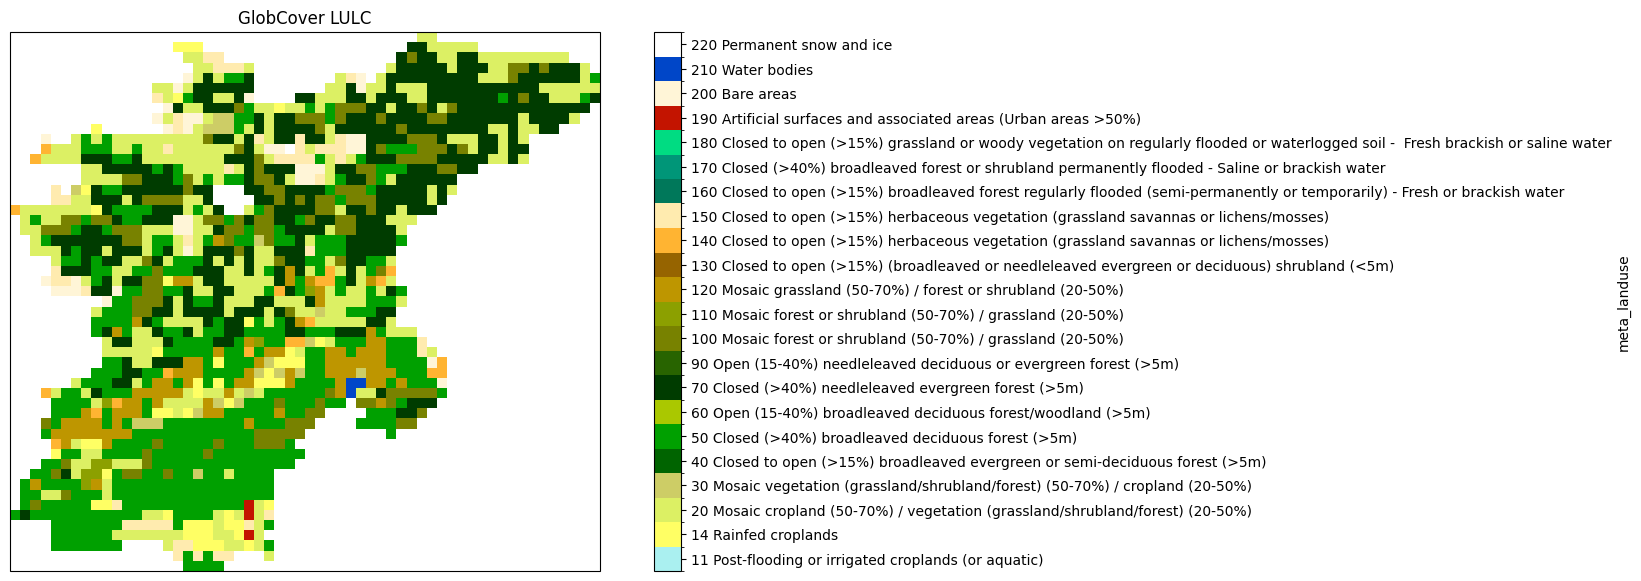

In [9]:
df = pd.read_csv("./legends/GLOBCOVER_2009_QGIS.txt", header=None, index_col=0)

# plot  globcover map
levels = df.index
colors = (df.iloc[:-1, :4] / 255).values
ticklabs = df.iloc[:-1, 4].values
cmap, norm = mpl.colors.from_levels_and_colors(levels, colors)
ticks = np.array(levels[:-1]) + np.diff(levels) / 2.0

# create new figure
fig = plt.figure(figsize=(14, 7))
ax = fig.add_subplot(projection=proj)
# plot globcover landuse
mask = model.staticmaps.data["subcatchment"] > 0
p = (
    model.staticmaps.data["meta_landuse"]
    .raster.mask_nodata()
    .plot(ax=ax, cmap=cmap, norm=norm, cbar_kwargs=dict(ticks=ticks))
)
p.axes.set_title("GlobCover LULC")
_ = p.colorbar.ax.set_yticklabels(ticklabs)

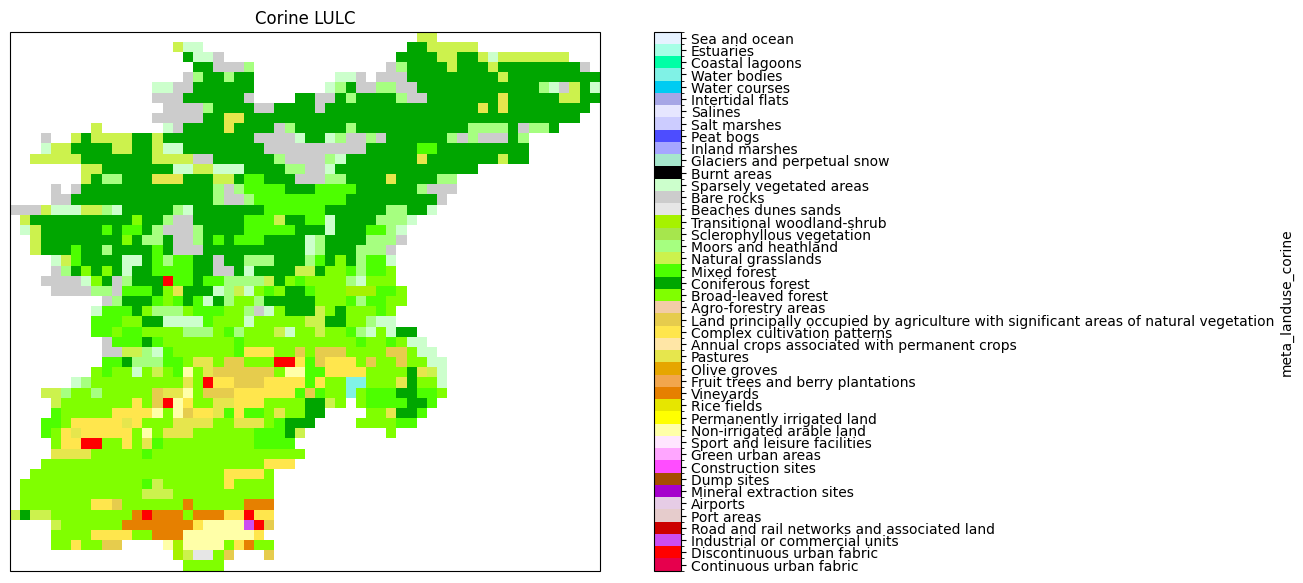

In [10]:
# plot  corine map
df = pd.read_csv(
    "./legends/CLC2018_CLC2018_V2018_20_QGIS.txt", header=None, index_col=0
)

# plot  corine map
levels = df.index
colors = (df.iloc[:-1, :4] / 255).values
ticklabs = df.iloc[:-1, 4].values
cmap, norm = mpl.colors.from_levels_and_colors(levels, colors)
ticks = np.array(levels[:-1]) + np.diff(levels) / 2.0

# create new figure
fig = plt.figure(figsize=(14, 7))
ax = fig.add_subplot(projection=proj)
# plot corine landuse
p = (
    model.staticmaps.data["meta_landuse_corine"]
    .raster.mask_nodata()
    .plot(ax=ax, cmap=cmap, norm=norm, cbar_kwargs=dict(ticks=ticks))
)
p.axes.set_title("Corine LULC")
_ = p.colorbar.ax.set_yticklabels(ticklabs)